# Shor 9-Qubit Code — Primitive & Syndrome-Based Correction

This notebook unifies two implementations of the Shor quantum error-correcting code.

| Part | Strategy | Knowledge of error |
|------|----------|--------------------|
| **A — Primitive** | Inject error, correct directly | ✅ Cheats (knows the error) |
| **B — Full** | Inject error, measure syndrome, decode, correct | ❌ Blind (real QEC) |

Both parts share the same encoding and error-injection infrastructure.

## Theory: The Shor Code

The **Shor 9-qubit code** is a **concatenated CSS code** that can correct *any* single-qubit error (X, Z, or Y = XZ).

### Structure: two nested repetition codes

```
Outer layer  →  phase-flip repetition (3 blocks)
  Block 0: q0 q1 q2
  Block 1: q3 q4 q5
  Block 2: q6 q7 q8
Inner layer  →  bit-flip repetition within each block
```

### Logical codewords

$$|0\rangle_L = \frac{(|000\rangle+|111\rangle)^{\otimes 3}}{2\sqrt{2}}, \qquad |1\rangle_L = \frac{(|000\rangle-|111\rangle)^{\otimes 3}}{2\sqrt{2}}$$

### Encoding circuit for $|0\rangle_L$ (input: all qubits in $|0\rangle$)

1. **CX(0→3), CX(0→6)** — outer repetition: spread qubit 0 to the head of blocks 1 and 2  
2. **H on {0, 3, 6}** — rotate each block head from $|0\rangle/|1\rangle$ into the X-basis $|+\rangle/|-\rangle$  
3. **CX(i→i+1), CX(i→i+2)** for i ∈ {0,3,6} — inner bit-flip: entangle each head with its two partners

Result: each block is in $(|000\rangle + |111\rangle)/\sqrt{2}$ — the $|+\rangle$-encoded codeword.

### Stabilizers and what they detect

| Stabilizer | Qubits | Detects |
|------------|--------|---------|
| $Z_0Z_1$, $Z_1Z_2$ | block 0 | X error within block 0 |
| $Z_3Z_4$, $Z_4Z_5$ | block 1 | X error within block 1 |
| $Z_6Z_7$, $Z_7Z_8$ | block 2 | X error within block 2 |
| $X_0X_1X_2X_3X_4X_5$ | blocks 0&1 | Z error in block 0 or 1 |
| $X_3X_4X_5X_6X_7X_8$ | blocks 1&2 | Z error in block 1 or 2 |

A **Z error** flips the sign of the X-type stabilizers (phase syndrome).  
An **X error** flips the eigenvalue of the Z-type stabilizers (bit syndrome).  
A **Y error** = XZ triggers both.

### Qiskit bit-string ordering

Qiskit returns measurement results as **big-endian**: `result[0]` = `cr[n-1]` (highest index), `result[-1]` = `cr[0]` (index 0). Always reverse before indexing:
```python
syn_bits = bitstring[::-1]   # now syn_bits[i] == cr[i]
```

## Imports

In [1]:
import random
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram

## 1 · Encoding

`shor_encode()` builds the 9-qubit encoding circuit starting from $|0\rangle^{\otimes 9}$, producing the logical $|0\rangle_L$ state.

The function returns a `QuantumCircuit` with one named `QuantumRegister` (`'q'`) of 9 data qubits, so downstream functions can always retrieve the data register as `qc.qregs[0]`.

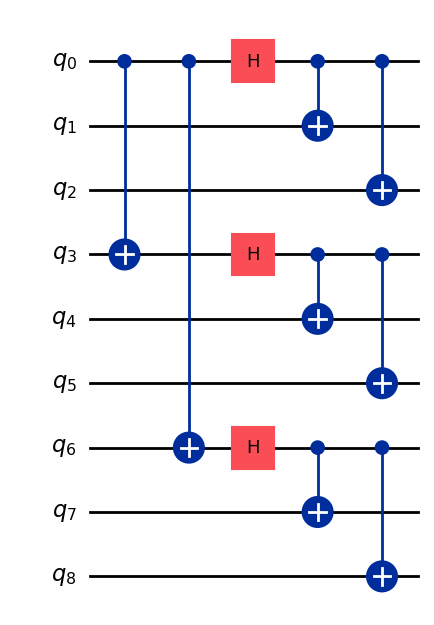

In [2]:
def shor_encode():
    """
    Build the Shor encoding circuit for |0>_L.

    Layout: 9 data qubits in QuantumRegister('q').
    Circuit action on |000000000>:
      Step 1 (outer): CX(0,3), CX(0,6)  -> q0 copied to block heads
      Step 2 (phase): H on {0,3,6}       -> rotate heads to |+>/<->
      Step 3 (inner): CX(i,i+1),(i,i+2) -> bit-flip repetition per block
    """
    data = QuantumRegister(9, 'q')
    qc   = QuantumCircuit(data)

    # ── Outer: phase-flip repetition ─────────────────────────────
    # Copies the logical bit from qubit 0 to the heads of blocks 1 and 2.
    # At this point we are still in the Z basis, so CX spreads |0>/|1> info.
    qc.cx(data[0], data[3])
    qc.cx(data[0], data[6])

    # ── Rotate block heads into X basis ──────────────────────────
    # H: |0> -> |+>, |1> -> |->  (enters the phase-encoding subspace)
    for i in [0, 3, 6]:
        qc.h(data[i])

    # ── Inner: bit-flip repetition within each block ─────────────
    # CX from head to each partner entangles into (|000>+|111>)/sqrt(2)
    # or (|000>-|111>)/sqrt(2) depending on the head's phase.
    for i in [0, 3, 6]:
        qc.cx(data[i], data[i + 1])
        qc.cx(data[i], data[i + 2])

    return qc

# Draw to inspect
shor_encode().draw('mpl', fold=-1)

## 2 · Error Injection

Two variants:
- `inject_error(qc)` — random qubit and error type (used in both parts)
- `inject_known_error(qc, qubit, error_type)` — deterministic injection (used in Part B to re-apply the *same* error on the correction circuit after the syndrome has been extracted)

Both retrieve the data register by name so they work regardless of which additional registers (ancilla, classical) have been attached.

In [3]:
def inject_error(qc):
    """
    Inject a random single-qubit error (X or Z) on a random data qubit.
    Returns (qubit_index, error_type) so the caller can store the result.
    """
    data  = qc.qregs[0]            # always the 9 data qubits
    qubit = random.randint(0, 8)
    etype = random.choice(['X', 'Z'])

    if etype == 'X':
        qc.x(data[qubit])          # bit-flip: swaps |0><->|1>
    else:
        qc.z(data[qubit])          # phase-flip: |1> -> -|1>, |0> unchanged

    print(f"Injected {etype} error on qubit {qubit}")
    return qubit, etype


def inject_known_error(qc, qubit, etype):
    """Re-apply a specific previously-stored error (used in Part B verification)."""
    data = qc.qregs[0]
    if etype == 'X':
        qc.x(data[qubit])
    elif etype == 'Z':
        qc.z(data[qubit])
    elif etype == 'Y':
        qc.y(data[qubit])

---
## Part A — Primitive (Cheat-Correct) Demo

Here we **already know** which error was injected (because we just injected it), so correction is trivial: apply the inverse gate to the same qubit. This is *not* real QEC — it's a baseline to confirm the circuit mechanics (encoding, error, inversion, measurement) produce the correct logical outcome.

Pedagogical value: verify that the Shor encoding + single error + direct correction returns the circuit to $|0\rangle_L$ before introducing the harder syndrome machinery.

In [4]:
def direct_correct(qc, qubit, etype):
    """
    Apply the inverse of a known error directly to the circuit.
    X^2 = Z^2 = I, so the correction is the same gate as the error.
    """
    data = qc.qregs[0]
    if etype == 'X':
        qc.x(data[qubit])   # X·X = I  -> undoes the bit-flip
    elif etype == 'Z':
        qc.z(data[qubit])   # Z·Z = I  -> undoes the phase-flip
    return qc

### Part A — Full pipeline

Injected Z error on qubit 0
Part A: corrected Z error on qubit 0


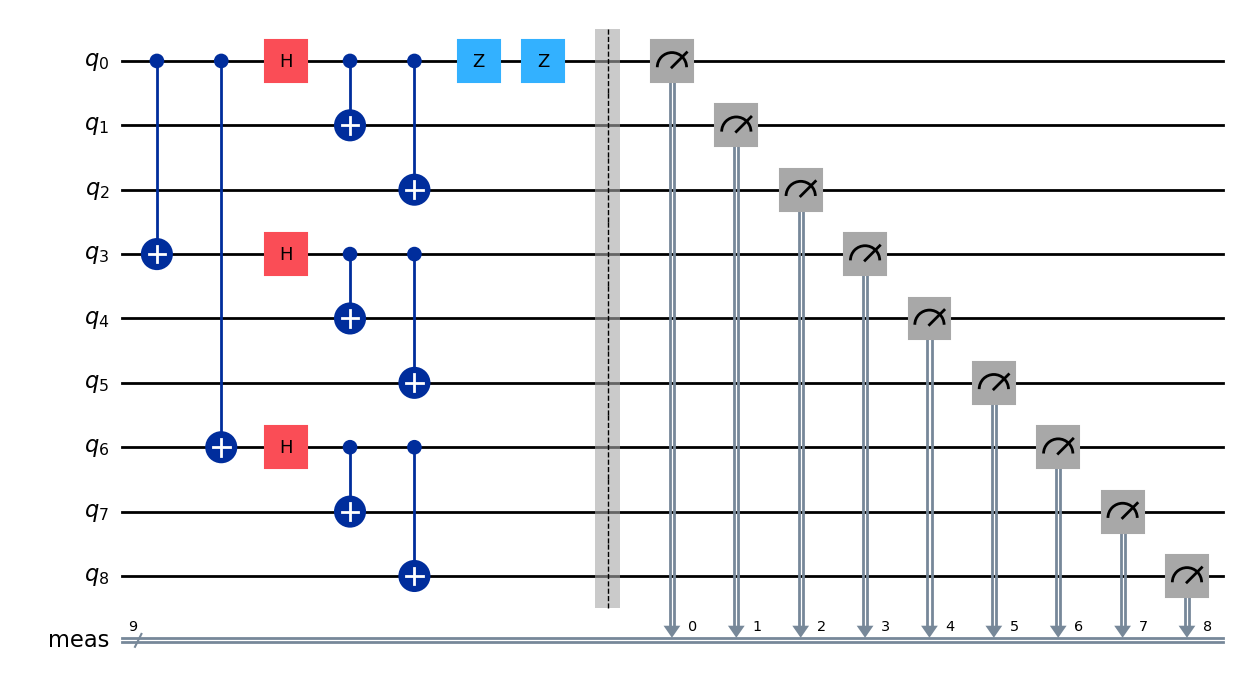

In [5]:
# ── Step 1: Encode ──────────────────────────────────────────────
qc_a = shor_encode()

# ── Step 2: Inject a random single-qubit error ──────────────────
err_qubit_a, err_type_a = inject_error(qc_a)

# ── Step 3: Direct correction (cheat: we know the error) ────────
qc_a = direct_correct(qc_a, err_qubit_a, err_type_a)

# ── Step 4: Measure all 9 data qubits ───────────────────────────
# measure_all() appends a new ClassicalRegister automatically.
qc_a.measure_all()

print(f"Part A: corrected {err_type_a} error on qubit {err_qubit_a}")
qc_a.draw('mpl', fold=-1)

### Part A — Simulation

Expected: all measurement outcomes belong to the $|0\rangle_L$ set — the 8 computational-basis strings where every block is uniformly $000$ or $111$:

```
000000000  000000111  000111000  000111111
111000000  111000111  111111000  111111111
```
Each appears with probability $1/8$ (1024/8 ≈ 128 shots each).

**Why 8 outcomes?**  Each block is in $(|000\rangle+|111\rangle)/\sqrt{2}$, so measuring collapses it to $|000\rangle$ or $|111\rangle$ with equal probability, independently for each of the 3 blocks → $2^3 = 8$ equally likely outcomes.

If an **X error remains uncorrected**, the affected block's outcomes shift to e.g. $|100\rangle/|011\rangle$, visibly displacing the histogram from the $|0\rangle_L$ support. If a **Z error** is uncorrected, the histogram is *identical* to $|0\rangle_L$ (phase errors are invisible to Z-basis measurement) — see the verification note in Part B.

Part A outcome counts:
  000000000: 131
  000000111: 139
  000111000: 116
  000111111: 114
  111000000: 131
  111000111: 134
  111111000: 124
  111111111: 135


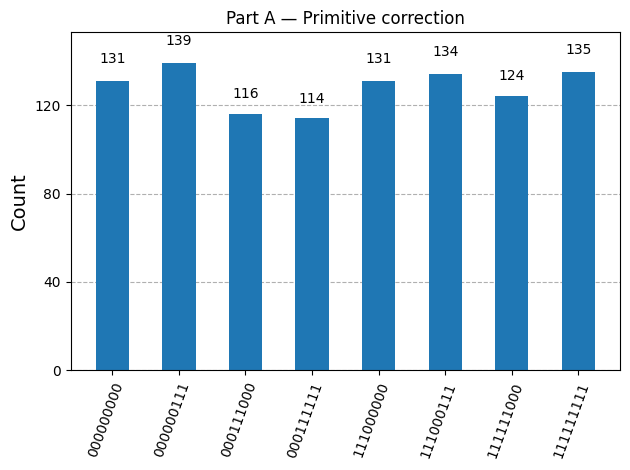

In [6]:
sim = AerSimulator()
compiled_a = transpile(qc_a, sim)
result_a  = sim.run(compiled_a, shots=1024).result()
counts_a  = result_a.get_counts()

print("Part A outcome counts:")
for k, v in sorted(counts_a.items()):
    print(f"  {k}: {v}")

plot_histogram(counts_a, title='Part A — Primitive correction')

---
## Part B — Full Syndrome-Based Correction

Now we correct the error **without ever knowing which error was injected**. The workflow is:

```
[Encode] ──> [Inject unknown error] ──> [Syndrome circuit]
                                               │
                                    Simulate (shots=1) → bitstring
                                               │
                                    Classical decode
                                    (bit_corr, phase_corr)
                                               │
[Encode] ──> [Re-inject same error] ──> [Apply corrections] ──> [Measure] ──> Verify
```

The syndrome circuit and the correction circuit are **separate**: the syndrome measurement is used only to learn which correction to apply, then a fresh circuit is run for the final measurement.

### Syndrome Measurement — Non-Destructive Ancilla Approach

**Why ancilla?**  In both original notebooks, syndrome measurement was attempted by chaining CX gates directly onto *data* qubits and then measuring those same data qubits. This is **destructive**: measuring a data qubit collapses it, destroying the quantum information that subsequent syndrome steps (especially the phase syndrome) need.

The correct approach uses **8 dedicated ancilla qubits** initialised in $|0\rangle$:

```
anc_b[0..5]  — 6 ancilla for Z-type stabilisers (bit-flip syndrome)
anc_p[0..1]  — 2 ancilla for X-type stabilisers (phase-flip syndrome)
```

Each ancilla accumulates the parity of its stabiliser via CX gates, then is measured. Because *only ancilla are measured* (not data), the data qubits remain coherent throughout.

**Bit-flip syndrome** (Z-type, 6 bits):

| Ancilla | Measures | Circuit |
|---------|----------|---------|
| `ab[0]` | $Z_0 Z_1$ | CX(q0,ab0), CX(q1,ab0) — ab0 = q0⊕q1 |
| `ab[1]` | $Z_1 Z_2$ | CX(q1,ab1), CX(q2,ab1) |
| `ab[2]` | $Z_3 Z_4$ | CX(q3,ab2), CX(q4,ab2) |
| `ab[3]` | $Z_4 Z_5$ | CX(q4,ab3), CX(q5,ab3) |
| `ab[4]` | $Z_6 Z_7$ | CX(q6,ab4), CX(q7,ab4) |
| `ab[5]` | $Z_7 Z_8$ | CX(q7,ab5), CX(q8,ab5) |

**Phase-flip syndrome** (X-type, 2 bits) — measured in the H-rotated (X) basis:

Apply H to all data qubits, then:

| Ancilla | Measures | Meaning |
|---------|----------|---------|
| `ap[0]` | $X_0X_1X_2X_3X_4X_5$ | CX(q0..q5 → ap0): parity(block0) ⊕ parity(block1) |
| `ap[1]` | $X_3X_4X_5X_6X_7X_8$ | CX(q3..q8 → ap1): parity(block1) ⊕ parity(block2) |

Apply H back to data. After H, $(|000\rangle+|111\rangle)/\sqrt{2}$ maps to *even-parity* X-basis states and $(|000\rangle-|111\rangle)/\sqrt{2}$ (Z-error flipped) maps to *odd-parity* X-basis states — making Z errors directly visible as parity mismatches between blocks.

> **Note on ordering in notebook 2 (original bug):** the phase syndrome used a CX *chain* (CX(0,3), CX(3,6)) that accumulated qubits 0⊕3⊕6 rather than comparing block parities, and measured *data qubits* 6 and 7 directly — both incorrect.

In [7]:
def measure_syndrome(qc):
    """
    Append 8 ancilla qubits and 8 syndrome bits to qc.
    Performs non-destructive stabiliser measurement:
      syn[0..5] : Z-type (bit-flip), 2 bits per block
      syn[6..7] : X-type (phase-flip), one per adjacent block pair

    Returns the modified circuit.
    """
    data  = qc.qregs[0]            # the 9 original data qubits
    anc_b = QuantumRegister(6, 'ab')  # ancilla for bit-flip syndromes
    anc_p = QuantumRegister(2, 'ap')  # ancilla for phase-flip syndromes
    syn   = ClassicalRegister(8, 'syn')
    qc.add_register(anc_b)
    qc.add_register(anc_p)
    qc.add_register(syn)

    # ── Z-type stabilisers: parity checks within each block ─────
    # CX(a, anc), CX(b, anc) -> anc = a XOR b  (starts in |0>)
    # Eigenvalue (-1)^(a XOR b): 0 = same -> no X error, 1 = differ -> X error

    # Block 0 (q0,q1,q2)
    qc.cx(data[0], anc_b[0]); qc.cx(data[1], anc_b[0])  # Z0Z1
    qc.cx(data[1], anc_b[1]); qc.cx(data[2], anc_b[1])  # Z1Z2
    # Block 1 (q3,q4,q5)
    qc.cx(data[3], anc_b[2]); qc.cx(data[4], anc_b[2])  # Z3Z4
    qc.cx(data[4], anc_b[3]); qc.cx(data[5], anc_b[3])  # Z4Z5
    # Block 2 (q6,q7,q8)
    qc.cx(data[6], anc_b[4]); qc.cx(data[7], anc_b[4])  # Z6Z7
    qc.cx(data[7], anc_b[5]); qc.cx(data[8], anc_b[5])  # Z7Z8

    # Measure bit-flip ancilla into syn[0..5]
    for i in range(6):
        qc.measure(anc_b[i], syn[i])

    # ── X-type stabilisers: phase comparison between blocks ──────
    # Rotate data to X basis: H maps |+>->|0> and |->->|1>.
    # In this basis, (|000>+|111>)/sqrt(2) becomes EVEN-parity states
    # and (|000>-|111>)/sqrt(2) (Z-error victim) becomes ODD-parity states.
    for i in range(9):
        qc.h(data[i])

    # ap[0]: parity(block0) XOR parity(block1)
    #   = 0 if blocks have same phase, 1 if they differ
    for i in [0, 1, 2, 3, 4, 5]:
        qc.cx(data[i], anc_p[0])
    qc.measure(anc_p[0], syn[6])

    # ap[1]: parity(block1) XOR parity(block2)
    for i in [3, 4, 5, 6, 7, 8]:
        qc.cx(data[i], anc_p[1])
    qc.measure(anc_p[1], syn[7])

    # Rotate data back to Z basis
    for i in range(9):
        qc.h(data[i])

    return qc

### Decoding — Classical Syndrome Lookup

**Qiskit bit-string reversal (critical fix vs. original notebook 2):**  
Qiskit returns the classical register as a big-endian string: `result[0]` = `syn[7]`, `result[-1]` = `syn[0]`. Calling `bitstring[::-1]` corrects this so `syn_bits[i]` == `syn[i]`.

**Bit-flip correction table** (per block, 2 syndrome bits):

| syn[2i] | syn[2i+1] | X error on qubit |
|---------|-----------|------------------|
| 0 | 0 | none |
| 1 | 0 | first qubit of block (3i) |
| 1 | 1 | second qubit (3i+1) |
| 0 | 1 | third qubit (3i+2) |

**Phase-flip correction table** (2 syndrome bits):

| syn[6] | syn[7] | Z error in block |
|--------|--------|------------------|
| 0 | 0 | none |
| 1 | 0 | block 0 → apply Z to qubit 0 |
| 1 | 1 | block 1 → apply Z to qubit 3 |
| 0 | 1 | block 2 → apply Z to qubit 6 |

Applying Z to *any single qubit* within the affected block is sufficient, because $Z_i \equiv Z_L$ (logical Z) for all $i$ within a block in the 3-qubit bit-flip code.

In [8]:
def decode_bit(syn_bits):
    """
    Decode bit-flip syndrome bits into a list of qubits needing X correction.

    syn_bits : 8-char string AFTER [::-1] reversal
               syn_bits[i] == measurement of syn register bit i
    syn_bits[0:2] -> block 0 (qubits 0,1,2)
    syn_bits[2:4] -> block 1 (qubits 3,4,5)
    syn_bits[4:6] -> block 2 (qubits 6,7,8)

    Table per block (s0 = ZaZb, s1 = ZbZc):
      '00' -> no X error
      '10' -> X on first qubit  (s0=1, s1=0)
      '11' -> X on middle qubit (s0=1, s1=1)
      '01' -> X on last qubit   (s0=0, s1=1)
    """
    corrections = []
    for blk, start in enumerate([0, 2, 4]):   # blocks 0, 1, 2
        s = syn_bits[start : start + 2]        # two syndrome bits for this block
        if s == '10':
            corrections.append(3 * blk)        # qubit 0, 3, or 6
        elif s == '11':
            corrections.append(3 * blk + 1)    # qubit 1, 4, or 7
        elif s == '01':
            corrections.append(3 * blk + 2)    # qubit 2, 5, or 8
        # '00' -> no correction needed
    return corrections


def decode_phase(syn_bits):
    """
    Decode phase-flip syndrome bits into a list of qubits needing Z correction.

    syn_bits[6] = s6: parity(block0) XOR parity(block1)  (in X basis)
    syn_bits[7] = s7: parity(block1) XOR parity(block2)

    Phase syndrome table:
      (0,0) -> no phase error
      (1,0) -> Z error in block 0 -> correct qubit 0
      (1,1) -> Z error in block 1 -> correct qubit 3
      (0,1) -> Z error in block 2 -> correct qubit 6
    """
    s6, s7 = int(syn_bits[6]), int(syn_bits[7])
    if s6 == 1 and s7 == 0:
        return [0]     # Z error in block 0
    elif s6 == 1 and s7 == 1:
        return [3]     # Z error in block 1
    elif s6 == 0 and s7 == 1:
        return [6]     # Z error in block 2
    return []          # no phase error


def apply_corrections(qc, bit_corr, phase_corr):
    """
    Apply X gates for bit-flip corrections and Z gates for phase-flip corrections.
    X and Z are self-inverse (X^2 = Z^2 = I), so each gate undoes the corresponding error.
    """
    data = qc.qregs[0]
    for q in bit_corr:
        qc.x(data[q])    # corrects X error: X·X = I
    for q in phase_corr:
        qc.z(data[q])    # corrects Z error: Z·Z = I
    return qc

### Part B — Step 1: Build & simulate the syndrome circuit

We run the syndrome circuit once (`shots=1`). Because the simulation is noiseless, the syndrome measurement is deterministic — the same qubit-error always produces the same syndrome bitstring. `shots=1` is therefore sufficient.

Injected X error on qubit 2

Syndrome circuit: 17 qubits (9 data + 6 bit-ancilla + 2 phase-ancilla)


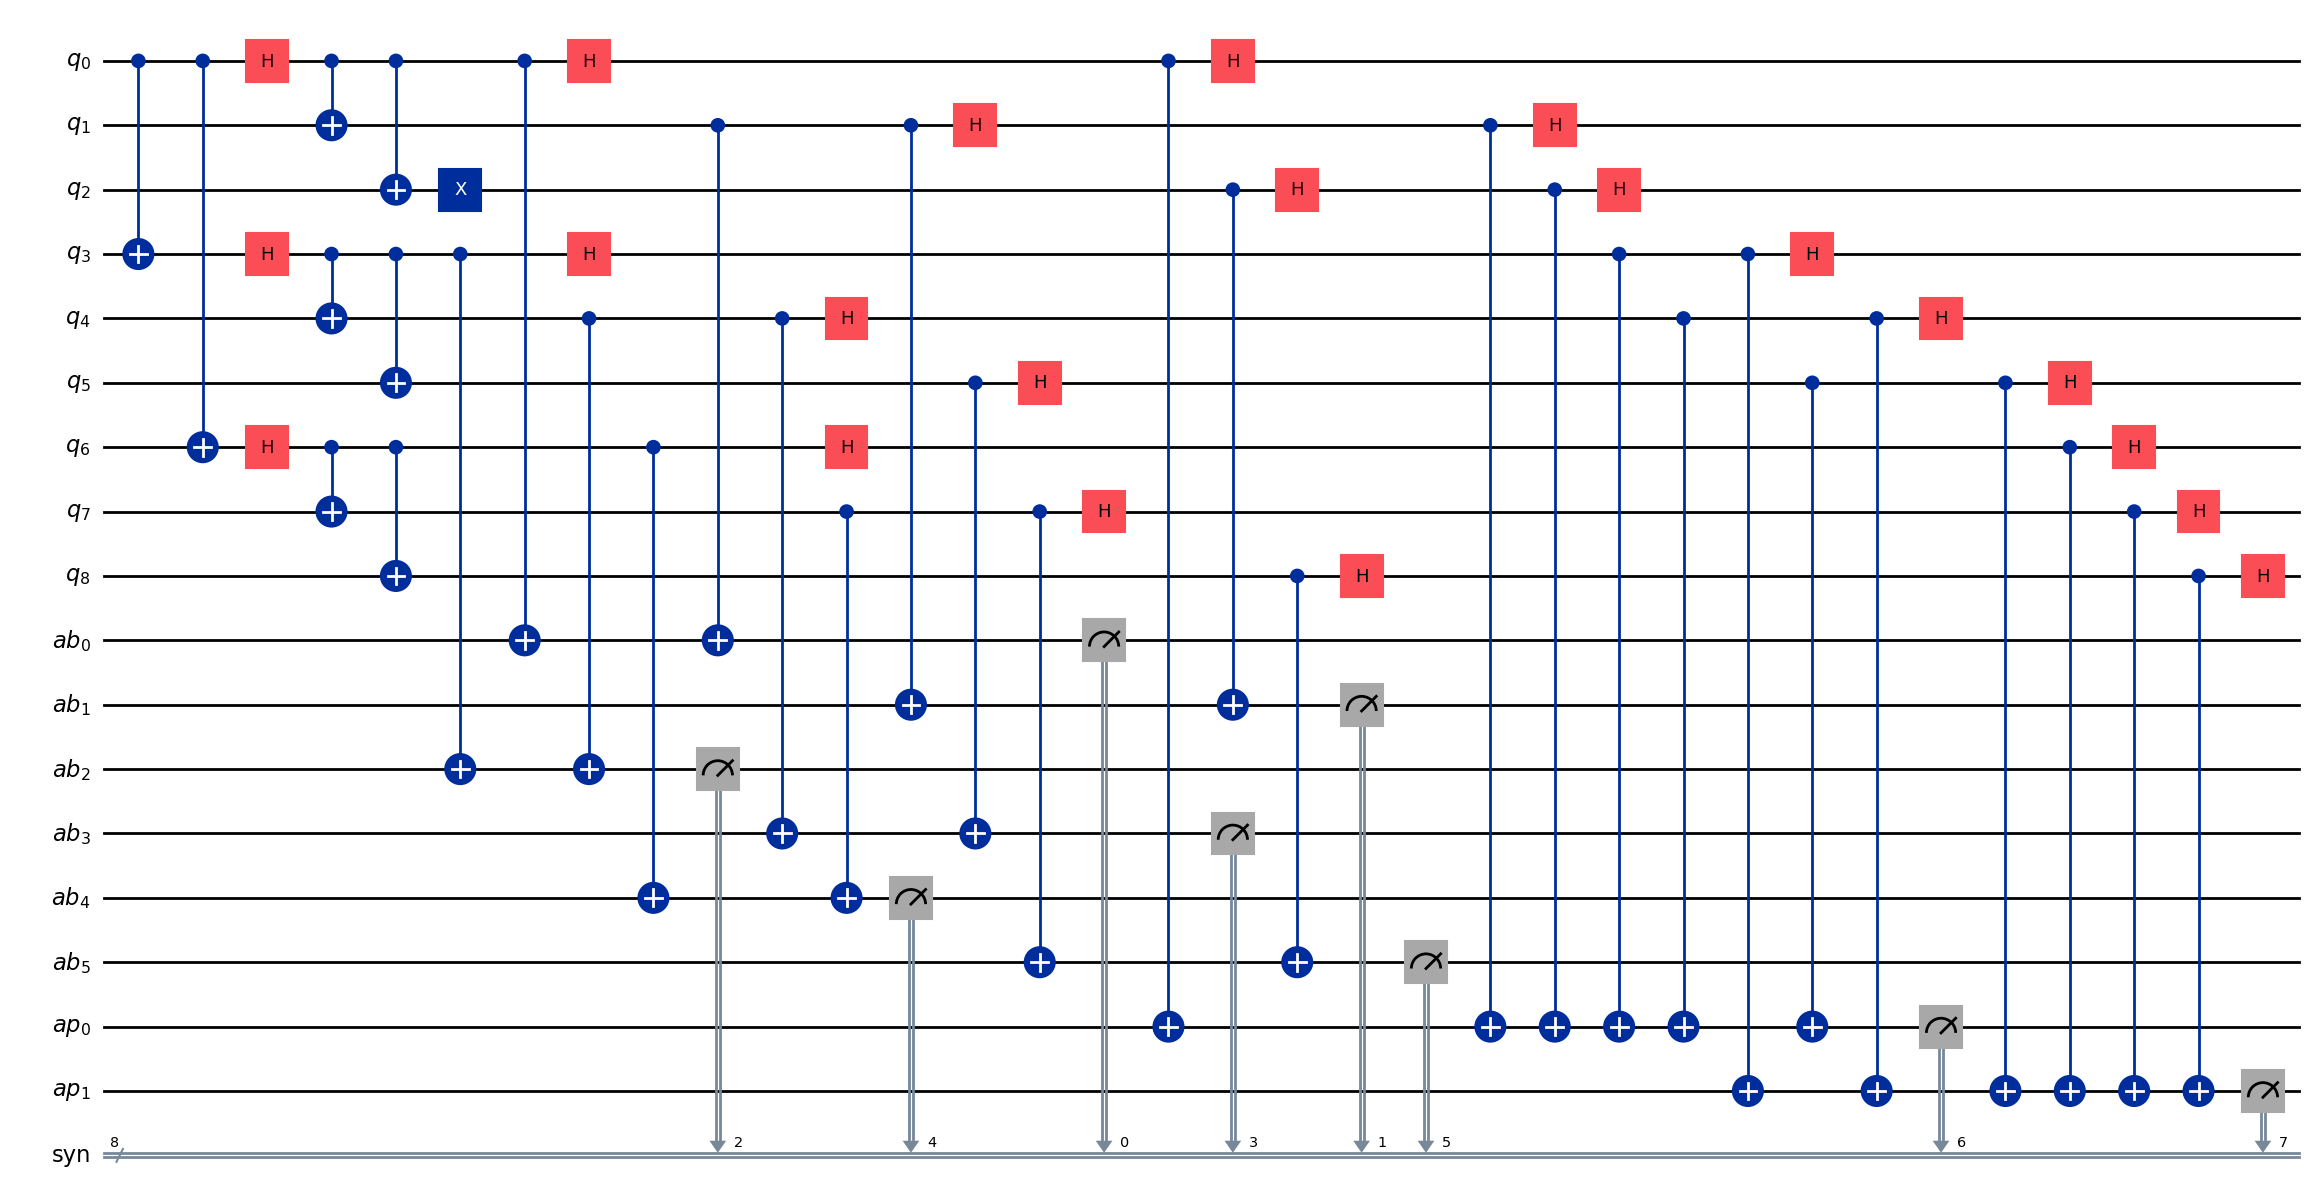

In [9]:
# ── Encode ──────────────────────────────────────────────────────
qc_syn = shor_encode()

# ── Inject random error (store qubit & type for verification) ───
err_qubit, err_type = inject_error(qc_syn)

# ── Append syndrome measurement circuit ─────────────────────────
qc_syn = measure_syndrome(qc_syn)

print(f"\nSyndrome circuit: {qc_syn.num_qubits} qubits "
      f"(9 data + 6 bit-ancilla + 2 phase-ancilla)")
qc_syn.draw('mpl', fold=-1)

In [10]:
# ── Simulate syndrome circuit ────────────────────────────────────
# AerSimulator handles mid-circuit measurements natively.
# shots=1 is fine for a noiseless deterministic syndrome.
sim_syn = AerSimulator()
compiled_syn = transpile(qc_syn, sim_syn)
result_syn   = sim_syn.run(compiled_syn, shots=1).result()
counts_syn   = result_syn.get_counts()

# The bitstring contains only the 8-bit syn register (no other registers).
raw_bitstring = list(counts_syn.keys())[0]
print(f"Raw bitstring (Qiskit big-endian, syn[7]..syn[0]): {raw_bitstring}")

# Reverse to get syn_bits[i] == syn[i]
syn_bits = raw_bitstring[::-1]
print(f"Corrected ordering (syn[0]..syn[7]):               {syn_bits}")
print(f"  Bit-flip bits  syn[0..5] = {syn_bits[0:6]}")
print(f"  Phase-flip bits syn[6..7] = {syn_bits[6:8]}")

Raw bitstring (Qiskit big-endian, syn[7]..syn[0]): 00000010
Corrected ordering (syn[0]..syn[7]):               01000000
  Bit-flip bits  syn[0..5] = 010000
  Phase-flip bits syn[6..7] = 00


### Part B — Step 2: Classical decode

Pass the corrected bitstring to both decoders. No quantum hardware needed for this step.

In [11]:
bit_corr   = decode_bit(syn_bits)
phase_corr = decode_phase(syn_bits)

print(f"True error  : {err_type} on qubit {err_qubit}")
print(f"Bit corrections  (X gates) on qubits: {bit_corr}")
print(f"Phase corrections (Z gates) on qubits: {phase_corr}")

# Sanity check
if err_type == 'X' and err_qubit in bit_corr:
    print("✅ Bit decoder correctly identified the X error.")
elif err_type == 'Z' and err_qubit in phase_corr:
    print("✅ Phase decoder correctly identified the Z error.")
elif err_type == 'Z' and phase_corr:
    print("✅ Phase decoder identified a Z error in the correct block.")
else:
    print("⚠️  Check syndrome decoding output above.")

True error  : X on qubit 2
Bit corrections  (X gates) on qubits: [2]
Phase corrections (Z gates) on qubits: []
✅ Bit decoder correctly identified the X error.


### Part B — Step 3: Correction circuit

We rebuild the state from scratch (encode → inject *same* error → apply syndrome-derived corrections → measure). This is the standard way to verify error correction in simulation:
the syndrome tells us the correction; we apply it and confirm the output matches $|0\rangle_L$.

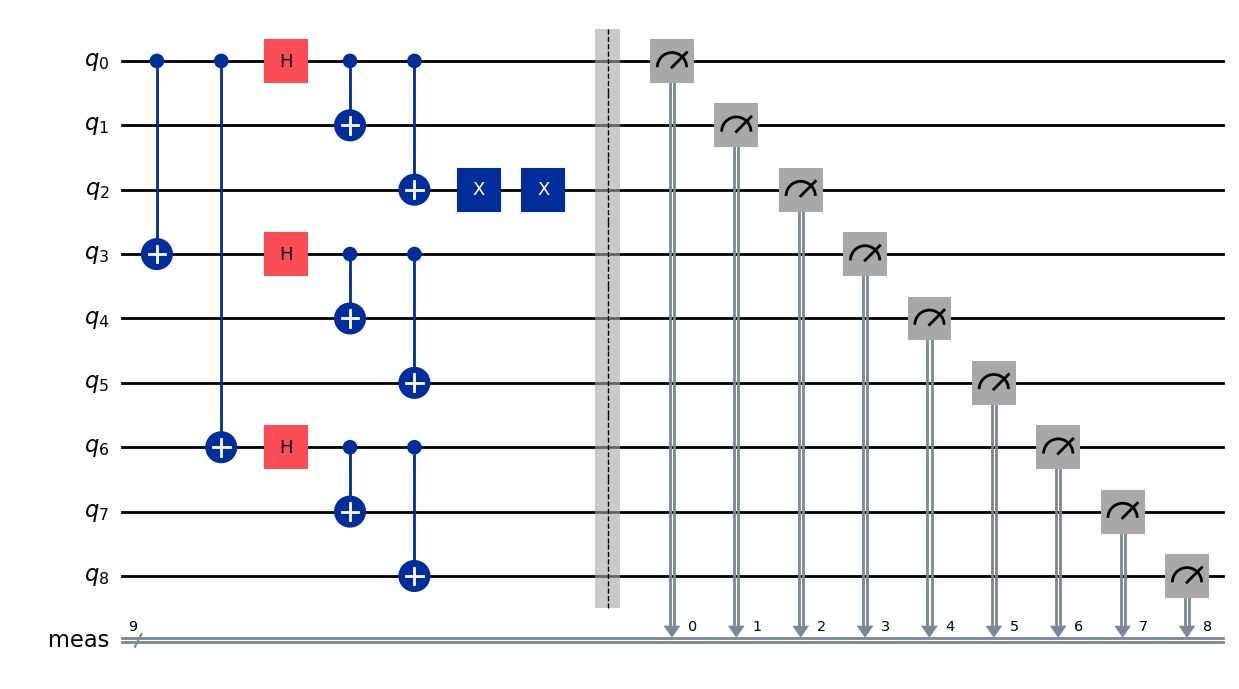

In [12]:
# ── Fresh encoding ───────────────────────────────────────────────
qc_corr = shor_encode()

# ── Re-inject the exact same error ───────────────────────────────
inject_known_error(qc_corr, err_qubit, err_type)

# ── Apply syndrome-derived corrections ───────────────────────────
qc_corr = apply_corrections(qc_corr, bit_corr, phase_corr)

# ── Measure all 9 data qubits ────────────────────────────────────
qc_corr.measure_all()

qc_corr.draw('mpl', fold=-1)

### Part B — Step 4: Simulate & verify

Part B outcome counts after correction:
  000000000: 117
  000000111: 121
  000111000: 122
  000111111: 162
  111000000: 104
  111000111: 129
  111111000: 135
  111111111: 134

All outcomes in |0>_L support? True


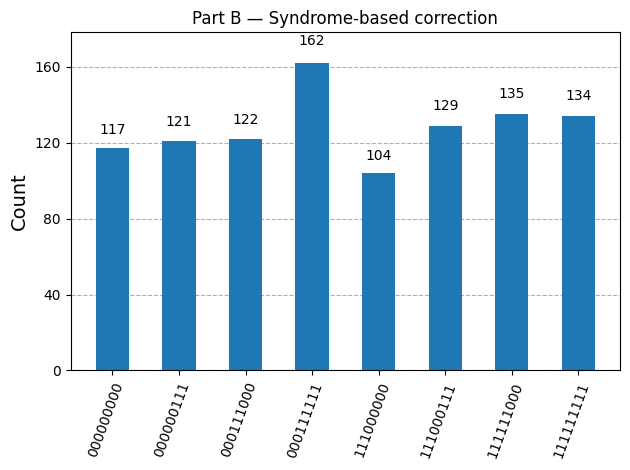

In [13]:
compiled_corr = transpile(qc_corr, sim)
result_corr   = sim.run(compiled_corr, shots=1024).result()
counts_corr   = result_corr.get_counts()

print("Part B outcome counts after correction:")
for k, v in sorted(counts_corr.items()):
    print(f"  {k}: {v}")

# The valid |0>_L outcomes: each of the 3 blocks is 000 or 111
valid_L0 = {
    f"{b2}{b1}{b0}"
    for b0 in ['000','111']
    for b1 in ['000','111']
    for b2 in ['000','111']
}
all_valid = all(k in valid_L0 for k in counts_corr)
print(f"\nAll outcomes in |0>_L support? {all_valid}")

plot_histogram(counts_corr, title='Part B — Syndrome-based correction')

### Verification note: X vs Z error detectability from histograms

**X errors** are histogram-verifiable. An uncorrected X error on qubit $k$ changes the block's codewords from $\{|000\rangle,|111\rangle\}$ to $\{|100\rangle,|011\rangle\}$ (for qubit 0), which is *visibly different* in the histogram.

**Z errors** are *not* histogram-verifiable in the Z basis. A Z gate changes amplitudes' signs but not their magnitudes, so $\|\langle x|\psi\rangle\|^2$ is identical for $|0\rangle_L$ and $Z_k|0\rangle_L$. To verify Z error correction, use **state fidelity**:

In [14]:
# ─── Fidelity check for Z error correction ───────────────────────
# Compare statevector of: (a) encoded |0>_L, (b) after error + correction.
# We strip the measurement and work on pure statevectors.

qc_ref = shor_encode()                          # reference: clean |0>_L

qc_check = shor_encode()                        # error + corrected circuit
inject_known_error(qc_check, err_qubit, err_type)
apply_corrections(qc_check, bit_corr, phase_corr)

sv_ref   = Statevector(qc_ref)
sv_check = Statevector(qc_check)

# Fidelity = |<ref|check>|^2  (global phase irrelevant)
fidelity = abs(sv_ref.inner(sv_check)) ** 2
print(f"Injected error     : {err_type} on qubit {err_qubit}")
print(f"Statevector fidelity after correction: {fidelity:.6f}")
if fidelity > 0.999:
    print("✅ Correction successful — state restored to |0>_L with fidelity ≈ 1.")
else:
    print("❌ Correction incomplete — check syndrome decoding.")

Injected error     : X on qubit 2
Statevector fidelity after correction: 1.000000
✅ Correction successful — state restored to |0>_L with fidelity ≈ 1.


---
## Summary Comparison

| Aspect | Part A (Primitive) | Part B (Full) |
|--------|--------------------|---------------|
| **Error knowledge** | Known at correction time | Unknown — derived from syndrome |
| **Syndrome** | Not measured | 8 stabiliser bits (6 bit + 2 phase) |
| **Ancilla qubits** | None | 8 ancilla (17 qubits total) |
| **Correction logic** | Apply inverse gate directly | Decode syndrome → lookup table |
| **Real-world applicability** | None (cheats) | Yes (standard QEC workflow) |
| **Verifiable by histogram** | ✅ (X errors clearly visible) | ✅ (X) + fidelity (Z) |

### Key fixes applied from the original notebooks

**Notebook 1 (Primitive):**
- `shor_encode()` — encoding logic was correct; now uses named `QuantumRegister` for clarity
- `measure_bit_syndrome()` — removed: was measuring *data* qubits, destroying the state
- `measure_phase_syndrome()` — removed: incorrect CX chain used data qubits as ancilla
- Replaced both with direct correction (Part A intent) and proper ancilla-based measurement (Part B)

**Notebook 2 (Full):**
- `measure_syndrome()` — complete rewrite: now uses 8 dedicated ancilla qubits
  - Bit syndrome: non-destructive CX(data,ancilla), measure ancilla only
  - Phase syndrome: correct H-basis parity comparison (CX from all qubits in both blocks to one ancilla), not a chain
- `decode_bit()` / `decode_phase()` — fixed **Qiskit big-endian bit reversal** (`[::-1]`); without this, the syndrome index mapping was wrong for all errors
- `decode_phase()` — now indexes `syn_bits[6]` and `syn_bits[7]` correctly (previously `syn_bits[6:8]` pointed to the wrong register bits)
- Full pipeline step 5 — clarified: rebuilds a fresh circuit, re-injects same error, applies correction; fidelity check added for Z errors
- `apply_corrections()` — unchanged in logic; now explicitly returns `qc`
